## Welcome to the Data Exploration UMAP Tutorial
Here we will be using *coderdata* to generate UMAPs by model type, cancer type, and source. These will be run on each individual dataset as well as all of them joined together. These can be used to create some general hypotheses for further testing. 

We will be focusing on transcriptomics, however proteomics can be filled in using the exact same methods seen below.  
- You can find and replace "transcriptomics" with "proteomics" and there are only a couple small adjustments needed to get it to run.

A note, UMAPs are easy to make and interpret but clusters are not guaranteed to be meaningful or consistent. This is best used as a method to generate hypotheses and display possible trends.

A second note - this tutorial uses coderdata 0.1.22. Some updates will occur that will likly break it.

### Import Packages

In [1]:
import pandas as pd
import coderdata as cd
import umap
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

### Load all Datasets
Load Datasets into respective objects. Then merge them into joined datasets.

In [53]:
# Load in all Datasets
# You may need to rename cell_line_experiments.tsv to cell_line_experiments.tsv. This will be fixed in updated package versions.
hcmi = cd.DatasetLoader('hcmi')
beataml = cd.DatasetLoader('beataml')
depmap = cd.DatasetLoader('tumor')
cptac = cd.DatasetLoader('cptac')

In [3]:
#Fix issues. This should be fixed by build updates and wont be needed in the future.
cptac.mutations = cptac.mutations.rename(columns={"mutation": "mutations"})
cptac.copy_number = cptac.copy_number.rename(columns={"CNV": "copy_number"})

In [4]:
# Join BeatAML and HCMI
joined_dataset1 = cd.join_datasets(beataml, hcmi)


Processing Data...


In [5]:
# Join DepMap and CPTAC
joined_dataset2 = cd.join_datasets(depmap, cptac)


Processing Data...


In [6]:
# Join All Datasets
joined_dataset3 = cd.join_datasets(joined_dataset1,joined_dataset2)

Processing Data...


In [7]:
# #Clean up extra columns - this also should be fixed on the package dev side.
joined_dataset3.transcriptomics["source"] = joined_dataset3.transcriptomics['source_x_x'].combine_first(joined_dataset3.transcriptomics['source_x_y']).combine_first(joined_dataset3.transcriptomics['source_y_x']).combine_first(joined_dataset3.transcriptomics['source_y_y'])
joined_dataset3.transcriptomics['study'] = joined_dataset3.transcriptomics['study_x_x'].combine_first(joined_dataset3.transcriptomics['study_x_y']).combine_first(joined_dataset3.transcriptomics['study_y_x']).combine_first(joined_dataset3.transcriptomics['study_y_y'])
joined_dataset3.transcriptomics = joined_dataset3.transcriptomics[["improve_sample_id","transcriptomics","entrez_id","source","study"]]

In [8]:
#Clean up extra columns - this also should be fixed on the package dev side.
joined_dataset3.samples["common_name"] = joined_dataset3.samples['common_name_x_x'].combine_first(joined_dataset3.samples['common_name_y_x']).combine_first(joined_dataset3.samples['common_name_x_y']).combine_first(joined_dataset3.samples['common_name_y_y'])
joined_dataset3.samples= joined_dataset3.samples.drop(['common_name_x_x', 'common_name_y_x',"common_name_y_y","common_name_x_y"], axis=1)

#### Initialize Mapping Directories
These mapping directories will be used to map samples (improve_sample_id) to model type, cancer type, common name, and source.  


In [9]:
# Model Type Mapping
model_type_dict = {
    'Solid Tissue': 'tumor',
    'tumor': 'tumor',
    "organoid" : "organoid",
    'cell line': 'cell line',
    'Tumor': 'tumor',
    'ex vivo': 'tumor',
    '3D Organoid': 'organoid',
    'Peripheral Blood Components NOS': 'tumor',
    'Buffy Coat': np.nan,
     None: np.nan,
    'Peripheral Whole Blood': 'tumor',
    'Adherent Cell Line': 'cell line',
    '3D Neurosphere': 'organoid',
    '2D Modified Conditionally Reprogrammed Cells': 'cell line',
    'Pleural Effusion': np.nan,
    'Human Original Cells': 'cell line',
    'Not Reported': np.nan, 
    'Mixed Adherent Suspension': 'cell line',
    'Cell': 'cell line',
    'Saliva': np.nan
    }

model_type_sample_map = dict(zip(joined_dataset3.samples['improve_sample_id'], joined_dataset3.samples['model_type']))
common_name_sample_map = dict(zip(joined_dataset3.samples['improve_sample_id'], joined_dataset3.samples['common_name']))
cancer_type_sample_map = dict(zip(joined_dataset3.samples['improve_sample_id'], joined_dataset3.samples['cancer_type']))

source_sample_map = dict(zip(joined_dataset3.transcriptomics['improve_sample_id'], joined_dataset3.transcriptomics['source']))


### Reformat transcriptomics Data
Convert the transcriptomics data from default (long) to wide.

In [10]:
joined_dataset3.reformat_dataset("transcriptomics","wide")

transcriptomics successfully converted to wide format


### Store improve_sample_id to a Seperate Dataframe
We store improve_sample_id to a seperate dataframe. This will be used to link information to the umap embeddings.  
Retreivable data: model_type, source.

In [11]:
jd3_sample_col = joined_dataset3.transcriptomics.iloc[:, 0].to_frame()
jd3_sample_col['model_type'] = jd3_sample_col['improve_sample_id'].map(model_type_sample_map)
jd3_sample_col['model_type'] = jd3_sample_col['model_type'].map(model_type_dict)
jd3_sample_col['source'] = jd3_sample_col['improve_sample_id'].map(source_sample_map)
jd3_sample_col['cancer_type'] = jd3_sample_col['improve_sample_id'].map(cancer_type_sample_map)


### Format The transcriptomics Data into Wide Format for the UMAP
This method could be used for transcriptomics or other data types as well.   
The points in the UMAP are in the same order as jd3_sample_col, so these can still be colored and labeled.

In [12]:
joined_dataset3.transcriptomics = joined_dataset3.transcriptomics.drop(joined_dataset3.transcriptomics.columns[:1], axis=1)

### Impute transcriptomics Data
Here we use the median of each column to fill in NAN values.  
This is a low precision method and you may wish to use other methods here.


In [13]:
for column in joined_dataset3.transcriptomics.columns:
    median_value = joined_dataset3.transcriptomics[column].median()
    joined_dataset3.transcriptomics[column].fillna(median_value, inplace=True)
joined_dataset3.transcriptomics = joined_dataset3.transcriptomics.dropna(axis='columns', how='all')

### Run UMAP Functions 
Data is scaled, transformed and embedded using the UMAP functions from umap-learn.

In [14]:
reducer = umap.UMAP()
t_full_data = joined_dataset3.transcriptomics.values
scaled_t_full_data = StandardScaler().fit_transform(t_full_data)
embedding_t_full_data = reducer.fit_transform(scaled_t_full_data)
embedding_t_full_data.shape

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


(3706, 2)

### Plot All Datasets UMAP by Model Type
In this plot, we are using model type (Organoid, Tumor, Cell Line, Other), labels. In this example, I've hidden the points that map to Other model_types - these include saliva, buffy coat, etc. The Other model_types will likely be removed from the coderdata package. 

Text(0.5, 1.0, 'All Datasets, transcriptomics UMAP by Model Type')

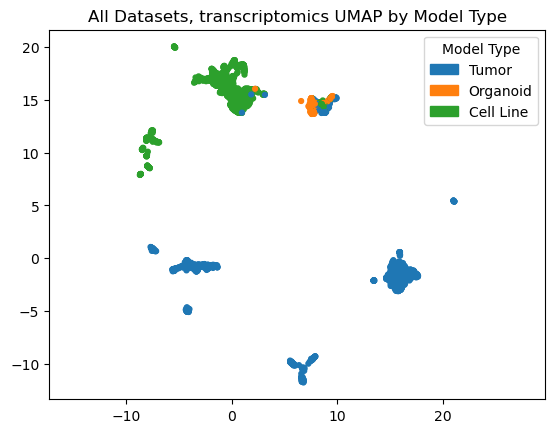

In [15]:
#plot umap. Hide/unhide unknowns

legend_handles = [
    mpatches.Patch(color=sns.color_palette()[0], label='Tumor'),  
    mpatches.Patch(color=sns.color_palette()[1], label='Organoid'),
    mpatches.Patch(color=sns.color_palette()[2], label='Cell Line')
    # mpatches.Patch(color=sns.color_palette()[3], label='Other')  # Uncomment this to include the Other model type legend label.
]

# This is used to hide the Unknown model types.
alphas = [0 if x == 3 else 1 for x in jd3_sample_col.model_type.map({"tumor": 0, "organoid": 1, "cell line": 2, np.nan: 3})]

plt.scatter(
    embedding_t_full_data[:, 0],
    embedding_t_full_data[:, 1],
    c=[sns.color_palette()[x] for x in jd3_sample_col.model_type.map({"tumor": 0, "organoid": 1, "cell line": 2, np.nan: 3})],
    alpha=alphas,  # Apply the alpha values here
    s=12
)
plt.gca().set_aspect('equal', 'datalim')

plt.legend(handles=legend_handles, title='Model Type')
plt.title('All Datasets, transcriptomics UMAP by Model Type', fontsize=12)

### Plot All Datasets UMAP Within Organoid Model Type

In [16]:
reducer = umap.UMAP()
t_full_organoid_data = joined_dataset3.transcriptomics[jd3_sample_col.model_type == "organoid"].values
scaled_t_full_organoid_data = StandardScaler().fit_transform(t_full_organoid_data)
embedding_t_full_organoid_data = reducer.fit_transform(scaled_t_full_organoid_data)
embedding_t_full_organoid_data.shape

(192, 2)

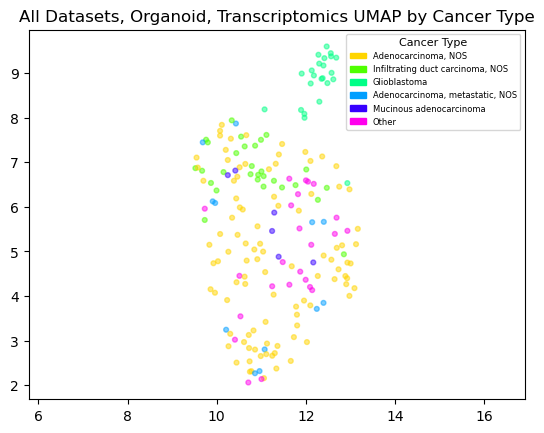

In [39]:

top_5_cancer_types = jd3_sample_col[jd3_sample_col.model_type == "organoid"].cancer_type.value_counts().head(5).index

# Create a new column for mapping colors
jd3_sample_col['organoid_color_group'] = jd3_sample_col.apply(lambda row: row.cancer_type if row.cancer_type in top_5_cancer_types else 'Other', axis=1)

# Create a color palette with one color for each of the top 5 types plus one for "Other"
unique_groups = pd.concat([pd.Series(top_5_cancer_types), pd.Series(['Other'])])
colors = sns.color_palette("hsv", len(unique_groups))
color_map = dict(zip(unique_groups, colors))

# Map the color_group column to actual colors
jd3_sample_col['color'] = jd3_sample_col['organoid_color_group'].map(color_map)

# Plotting
plt.scatter(
    embedding_t_full_organoid_data[:, 0],
    embedding_t_full_organoid_data[:, 1],
    c=jd3_sample_col[jd3_sample_col.model_type == "organoid"]['color'],  # Use the mapped colors
    alpha=0.5,  # Adjust alpha as needed
    s=12
)

# Adjust legend to reflect new grouping
legend_handles = [mpatches.Patch(color=color_map[group], label=group) for group in unique_groups]
# plt.legend(handles=legend_handles, title='Cancer Type')
plt.gca().set_aspect('equal', 'datalim')
plt.legend(handles=legend_handles, title='Cancer Type', prop={'size': 6}, title_fontsize=8)
plt.title('All Datasets, Organoid, Transcriptomics UMAP by Cancer Type', fontsize=12)
plt.show()



### Plot All Datasets UMAP Within Cell Line Model Type

In [ ]:
reducer = umap.UMAP()
t_full_cell_line_data = joined_dataset3.transcriptomics[jd3_sample_col.model_type == "cell line"].values
scaled_t_full_cell_line_data = StandardScaler().fit_transform(t_full_cell_line_data)
embedding_t_full_cell_line_data = reducer.fit_transform(scaled_t_full_cell_line_data)
embedding_t_full_cell_line_data.shape

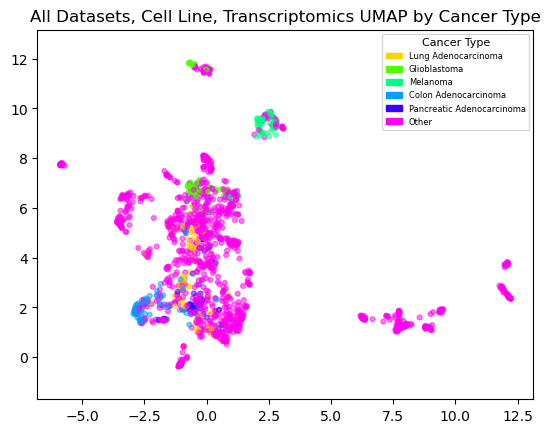

In [42]:

top_5_cancer_types = jd3_sample_col[jd3_sample_col.model_type == "cell line"].cancer_type.value_counts().head(5).index

# Create a new column for mapping colors
jd3_sample_col['cell_line_color_group'] = jd3_sample_col.apply(lambda row: row.cancer_type if row.cancer_type in top_5_cancer_types else 'Other', axis=1)

# Create a color palette with one color for each of the top 5 types plus one for "Other"
unique_groups = pd.concat([pd.Series(top_5_cancer_types), pd.Series(['Other'])])
colors = sns.color_palette("hsv", len(unique_groups))
color_map = dict(zip(unique_groups, colors))

# Map the color_group column to actual colors
jd3_sample_col['color'] = jd3_sample_col['cell_line_color_group'].map(color_map)

# Plotting
plt.scatter(
    embedding_t_full_cell_line_data[:, 0],
    embedding_t_full_cell_line_data[:, 1],
    c=jd3_sample_col[jd3_sample_col.model_type == "cell line"]['color'],  # Use the mapped colors
    alpha=0.5,  # Adjust alpha as needed
    s=12
)

# Adjust legend to reflect new grouping
legend_handles = [mpatches.Patch(color=color_map[group], label=group) for group in unique_groups]
# plt.legend(handles=legend_handles, title='Cancer Type')
plt.gca().set_aspect('equal', 'datalim')
plt.legend(handles=legend_handles, title='Cancer Type', prop={'size': 6}, title_fontsize=8)
plt.title('All Datasets, Cell Line, Transcriptomics UMAP by Cancer Type', fontsize=12)
plt.show()



### Plot All Datasets UMAP Within Tumor Model Type

In [43]:
reducer = umap.UMAP()
t_full_tumor_data = joined_dataset3.transcriptomics[jd3_sample_col.model_type == "tumor"].values
scaled_t_full_tumor_data = StandardScaler().fit_transform(t_full_tumor_data)
embedding_t_full_tumor_data = reducer.fit_transform(scaled_t_full_tumor_data)
embedding_t_full_tumor_data.shape

(1960, 2)

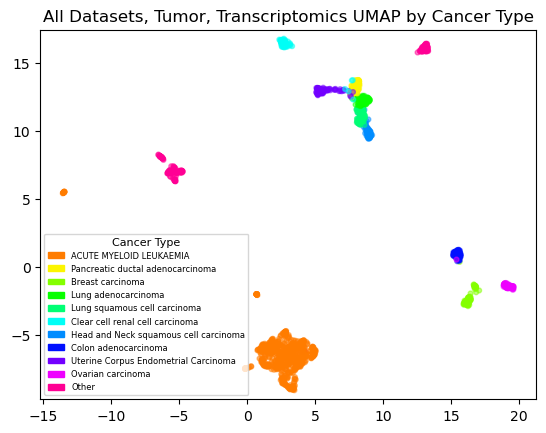

In [50]:

top_5_cancer_types = jd3_sample_col[jd3_sample_col.model_type == "tumor"].cancer_type.value_counts().head(10).index

# Create a new column for mapping colors
jd3_sample_col['tumor_color_group'] = jd3_sample_col.apply(lambda row: row.cancer_type if row.cancer_type in top_5_cancer_types else 'Other', axis=1)

# Create a color palette with one color for each of the top 5 types plus one for "Other"
unique_groups = pd.concat([pd.Series(top_5_cancer_types), pd.Series(['Other'])])
colors = sns.color_palette("hsv", len(unique_groups))
color_map = dict(zip(unique_groups, colors))

# Map the color_group column to actual colors
jd3_sample_col['color'] = jd3_sample_col['tumor_color_group'].map(color_map)

# Plotting
plt.scatter(
    embedding_t_full_tumor_data[:, 0],
    embedding_t_full_tumor_data[:, 1],
    c=jd3_sample_col[jd3_sample_col.model_type == "tumor"]['color'],  # Use the mapped colors
    alpha=0.5,  # Adjust alpha as needed
    s=12
)

# Adjust legend to reflect new grouping
legend_handles = [mpatches.Patch(color=color_map[group], label=group) for group in unique_groups]
# plt.legend(handles=legend_handles, title='Cancer Type')
plt.gca().set_aspect('equal', 'datalim')
plt.legend(handles=legend_handles, title='Cancer Type', prop={'size': 6}, title_fontsize=8)
plt.title('All Datasets, Tumor, Transcriptomics UMAP by Cancer Type', fontsize=12)
plt.show()



### Run UMAP for HCMI on Model Types
All of the code above is now applied to HCMI.

In [19]:
hcmi.reformat_dataset("transcriptomics","wide")
hcmi_sample_col = hcmi.transcriptomics.iloc[:, 0].to_frame()
hcmi_sample_col['model_type'] = hcmi_sample_col['improve_sample_id'].map(model_type_sample_map)
hcmi_sample_col['model_type'] = hcmi_sample_col['model_type'].map(model_type_dict)
hcmi.transcriptomics = hcmi.transcriptomics.drop(hcmi.transcriptomics.columns[:1], axis=1)
hcmi.transcriptomics
for column in hcmi.transcriptomics.columns:
    median_value = hcmi.transcriptomics[column].median()
    hcmi.transcriptomics[column].fillna(median_value, inplace=True)
hcmi.transcriptomics
reducer = umap.UMAP()
t_hcmi_data = hcmi.transcriptomics.values
scaled_t_hcmi_data = StandardScaler().fit_transform(t_hcmi_data)
embedding_t_hcmi_data = reducer.fit_transform(scaled_t_hcmi_data)
embedding_t_hcmi_data.shape

transcriptomics successfully converted to wide format


(436, 2)

Text(0.5, 1.0, 'HCMI, Transcriptomics UMAP by Model Type')

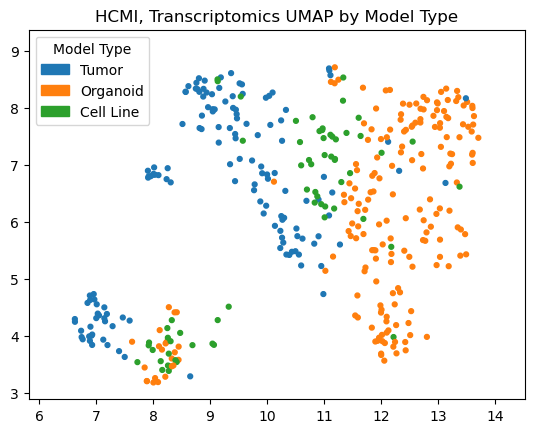

In [20]:
legend_handles = [
    mpatches.Patch(color=sns.color_palette()[0], label='Tumor'),  
    mpatches.Patch(color=sns.color_palette()[1], label='Organoid'),
    mpatches.Patch(color=sns.color_palette()[2], label='Cell Line')
]
alphas = [0 if x == 3 else 1 for x in hcmi_sample_col.model_type.map({"tumor": 0, "organoid": 1, "cell line": 2, np.nan: 3})]
plt.scatter(
    embedding_t_hcmi_data[:, 0],
    embedding_t_hcmi_data[:, 1],
    c=[sns.color_palette()[x] for x in hcmi_sample_col.model_type.map({"tumor": 0, "organoid": 1, "cell line": 2, np.nan: 3})],
    alpha=alphas,  # Apply the alpha values here
    s=12
)
plt.gca().set_aspect('equal', 'datalim')
plt.legend(handles=legend_handles, title='Model Type')
plt.title('HCMI, Transcriptomics UMAP by Model Type', fontsize=12)

### Run UMAP for BeatAML on Sample Types
All of the code above is now applied to BeatAML.

In [21]:
beataml.reformat_dataset("transcriptomics","wide")
beataml_sample_col = beataml.transcriptomics.iloc[:, 0].to_frame()
beataml_sample_col['common_name'] = beataml_sample_col['improve_sample_id'].map(common_name_sample_map)
# beataml_sample_col['model_type'] = beataml_sample_col['model_type'].map(model_type_dict)
beataml.transcriptomics = beataml.transcriptomics.drop(beataml.transcriptomics.columns[:1], axis=1)
beataml.transcriptomics
for column in beataml.transcriptomics.columns:
    median_value = beataml.transcriptomics[column].median()
    beataml.transcriptomics[column].fillna(median_value, inplace=True)
beataml.transcriptomics
reducer = umap.UMAP()
t_beataml_data = beataml.transcriptomics.values
scaled_t_beataml_data = StandardScaler().fit_transform(t_beataml_data)
embedding_t_beataml_data = reducer.fit_transform(scaled_t_beataml_data)
embedding_t_beataml_data.shape

transcriptomics successfully converted to wide format


(707, 2)

Text(0.5, 1.0, 'BeatAML, Transcriptomics UMAP by Sample Type')

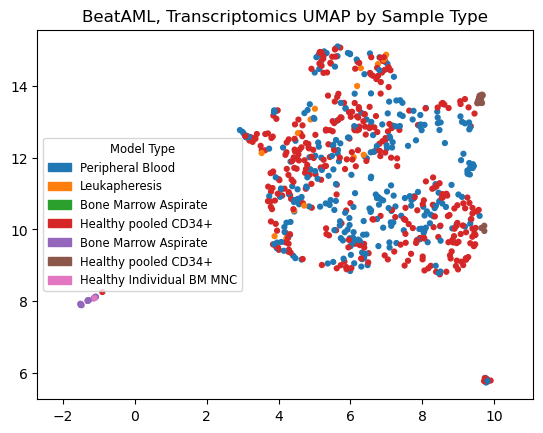

In [22]:
legend_handles = [
    mpatches.Patch(color=sns.color_palette()[0], label='Peripheral Blood'),  
    mpatches.Patch(color=sns.color_palette()[1], label='Leukapheresis'),
    mpatches.Patch(color=sns.color_palette()[2], label='Bone Marrow Aspirate'),
    mpatches.Patch(color=sns.color_palette()[3], label='Healthy pooled CD34+'),
    mpatches.Patch(color=sns.color_palette()[4], label='Bone Marrow Aspirate'),
    mpatches.Patch(color=sns.color_palette()[5], label='Healthy pooled CD34+'),
    mpatches.Patch(color=sns.color_palette()[6], label='Healthy Individual BM MNC'),
    # mpatches.Patch(color=sns.color_palette()[7], label='Healthy Individual CD34+'),
]
# Here we hide Healthy Individual CD34+ because there is only 1 sample.
alphas = [0 if x == 7 else 1 for x in beataml_sample_col.common_name.map({"Peripheral Blood": 0, "Leukapheresis": 1, "Healthy pooled CD34+": 2, 'Bone Marrow Aspirate': 3, 'Healthy pooled CD34+': 4,'Healthy Individual BM MNC':5,'Healthy Individual CD34+':6})]

plt.scatter(
    embedding_t_beataml_data[:, 0],
    embedding_t_beataml_data[:, 1],
    c=[sns.color_palette()[x] for x in beataml_sample_col.common_name.map({"Peripheral Blood": 0, "Leukapheresis": 1, "Healthy pooled CD34+": 2, 'Bone Marrow Aspirate': 3, 'Healthy pooled CD34+': 4,'Healthy Individual BM MNC':5,'Healthy Individual CD34+':6})],
    s=12,
    alpha=alphas
)
plt.gca().set_aspect('equal', 'datalim')
plt.legend(handles=legend_handles, title='Model Type', fontsize='small', title_fontsize='small')

plt.title('BeatAML, Transcriptomics UMAP by Sample Type', fontsize=12)

### Run UMAP for CPTAC on Cancer Types
All of the code above is now applied to CPTAC.
The plotting code below is condensed to avoid hard coding of cancer types.

In [23]:
cptac.reformat_dataset("transcriptomics","wide")
cptac_sample_col = cptac.transcriptomics.iloc[:, 0].to_frame()
cptac_sample_col['cancer_type'] = cptac_sample_col['improve_sample_id'].map(cancer_type_sample_map)
# cptac_sample_col['model_type'] = cptac_sample_col['model_type'].map(model_type_dict)
cptac.transcriptomics = cptac.transcriptomics.drop(cptac.transcriptomics.columns[:1], axis=1)
cptac.transcriptomics
for column in cptac.transcriptomics.columns:
    median_value = cptac.transcriptomics[column].median()
    cptac.transcriptomics[column].fillna(median_value, inplace=True)
cptac.transcriptomics
reducer = umap.UMAP()
t_cptac_data = cptac.transcriptomics.values
scaled_t_cptac_data = StandardScaler().fit_transform(t_cptac_data)
embedding_t_cptac_data = reducer.fit_transform(scaled_t_cptac_data)
embedding_t_cptac_data.shape

transcriptomics successfully converted to wide format


(1113, 2)

Text(0.5, 1.0, 'CPTAC, Transcriptomics UMAP by Cancer Type')

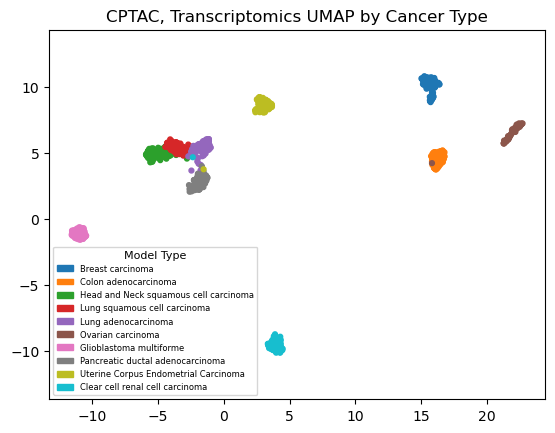

In [24]:
cancer_types = cptac.samples.cancer_type.unique()
colors = sns.color_palette(n_colors=len(cancer_types))

# Create legend handles dynamically
legend_handles = [mpatches.Patch(color=colors[i], label=label) for i, label in enumerate(cancer_types)]

color_mapping = {cancer_type: color for cancer_type, color in zip(cancer_types, colors)}

cptac_colors = cptac_sample_col.cancer_type.map(color_mapping).tolist()

plt.scatter(
    embedding_t_cptac_data[:, 0],
    embedding_t_cptac_data[:, 1],
    c=cptac_colors,
    s=12,
)

plt.gca().set_aspect('equal', 'datalim')
plt.legend(handles=legend_handles, title='Model Type', prop={'size': 6}, title_fontsize=8)
plt.title('CPTAC, Transcriptomics UMAP by Cancer Type', fontsize=12)


### Run UMAP for DepMap/Sanger on Top 8 Cancer Types
All of the code above is now applied to DepMap/Sanger.
However, due to the fact that there are over 200 cancer types, these are not easily plotable in a umap by color. As such, we will filter to just use cancer types that have more than 800 samples (top 8 cancers).


In [25]:
depmap = cd.DatasetLoader("depmap")
value_counts = depmap.samples['cancer_type'].value_counts()

# Filter to get names of cancer types with more than 800 occurrences
cancer_types_to_keep = value_counts[value_counts > 800].index

# Filter depmap.samples to only include these cancer types
filtered_samples = depmap.samples[depmap.samples['cancer_type'].isin(cancer_types_to_keep)]
improve_sample_ids_to_keep = filtered_samples['improve_sample_id'].unique().tolist()
depmap.transcriptomics = depmap.transcriptomics[depmap.transcriptomics['improve_sample_id'].isin(improve_sample_ids_to_keep)]

depmap.reformat_dataset("transcriptomics","wide")
depmap_sample_col = depmap.transcriptomics.iloc[:, 0].to_frame()
depmap_sample_col['cancer_type'] = depmap_sample_col['improve_sample_id'].map(cancer_type_sample_map)
# depmap_sample_col['model_type'] = depmap_sample_col['model_type'].map(model_type_dict)
depmap.transcriptomics = depmap.transcriptomics.drop(depmap.transcriptomics.columns[:1], axis=1)
depmap.transcriptomics
for column in depmap.transcriptomics.columns:
    median_value = depmap.transcriptomics[column].median()
    depmap.transcriptomics[column].fillna(median_value, inplace=True)
depmap.transcriptomics
reducer = umap.UMAP()
t_depmap_data = depmap.transcriptomics.values
scaled_t_depmap_data = StandardScaler().fit_transform(t_depmap_data)
embedding_t_depmap_data = reducer.fit_transform(scaled_t_depmap_data)
embedding_t_depmap_data.shape

Processing Data...
transcriptomics successfully converted to wide format


(436, 2)

Text(0.5, 1.0, 'DepMap, Transcriptomics UMAP by Top 8 Cancer Types')

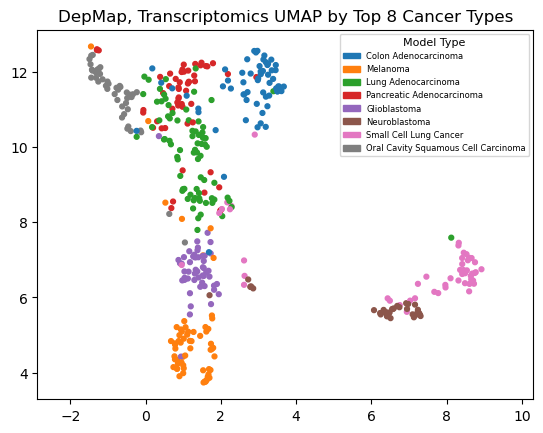

In [27]:
cancer_types = filtered_samples.cancer_type.unique()

colors = sns.color_palette(n_colors=len(cancer_types))

# Create legend handles dynamically
legend_handles = [mpatches.Patch(color=colors[i], label=label) for i, label in enumerate(cancer_types)]

color_mapping = {cancer_type: color for cancer_type, color in zip(cancer_types, colors)}

depmap_colors = depmap_sample_col.cancer_type.map(color_mapping).tolist()

plt.scatter(
    embedding_t_depmap_data[:, 0],
    embedding_t_depmap_data[:, 1],
    c=depmap_colors,
    s=12,
)

plt.gca().set_aspect('equal', 'datalim')
plt.legend(handles=legend_handles, title='Model Type', prop={'size': 6}, title_fontsize=8)
plt.title('DepMap, Transcriptomics UMAP by Top 8 Cancer Types', fontsize=12)


### Good luck creating your own UMAPs!